# Olivine hydrogen model

We first look at the iron measured with XRF. We then use this inventory to calculate how much hydrogen could form, how much could be collected, and how much electricity it could provide. We compare stationary, recirculating and once-through operation with a simple feedback model. Finally, we test transport through an assumed olivine bed with DARTS.

The XRF data do not measure reaction speed. Positive reaction times are scenarios; the zero-production case is kept as a reference. All iron is assumed ferrous and accessible for the main capacity comparison.

In [1]:
from pathlib import Path
import sys
import json
import csv
import contextlib
import io
from dataclasses import replace
import numpy as np
import pandas as pd
from IPython.display import display, Image

# Find the model folder when this notebook is opened from either project location.
choices = [Path.cwd(), Path.cwd().parent]
root = next(p for p in choices if (p / 'olivine_hydrogen' / 'batch.py').exists())
sys.path.insert(0, str(root))
model_dir = root / 'olivine_hydrogen'
print('Python used:', sys.executable)
assert 'darts-py311' in str(Path(sys.executable).resolve()), 'Select the shared DARTS interpreter.'


Python used: /Users/sanderbertdacosta/.local/share/python-envs/darts-py311/bin/python


## Reading the XRF data

The concentration and 2-Sigma columns have different meanings. We process them separately. Values below detection remain censored. The group labels follow the recorded reading numbers, so sorting the table does not move readings to a different group.

Matplotlib is building the font cache; this may take a moment.


,sample,n_readings,Fe_mean_wt_percent,Fe_sample_sd_wt_percent,magnetite_H2_kg_per_tonne_rock
0,sample1,5,5.845235,0.127496,0.703333
1,sample2,5,5.253344,0.765656,0.632113
2,sample3,6,7.305227,0.467058,0.879008
3,sample4,15,5.093717,0.568504,0.612906
4,sample5,10,6.038878,0.524968,0.726633
5,sample6,5,6.592921,0.558721,0.793299
6,sample7,10,6.323153,0.489778,0.760839


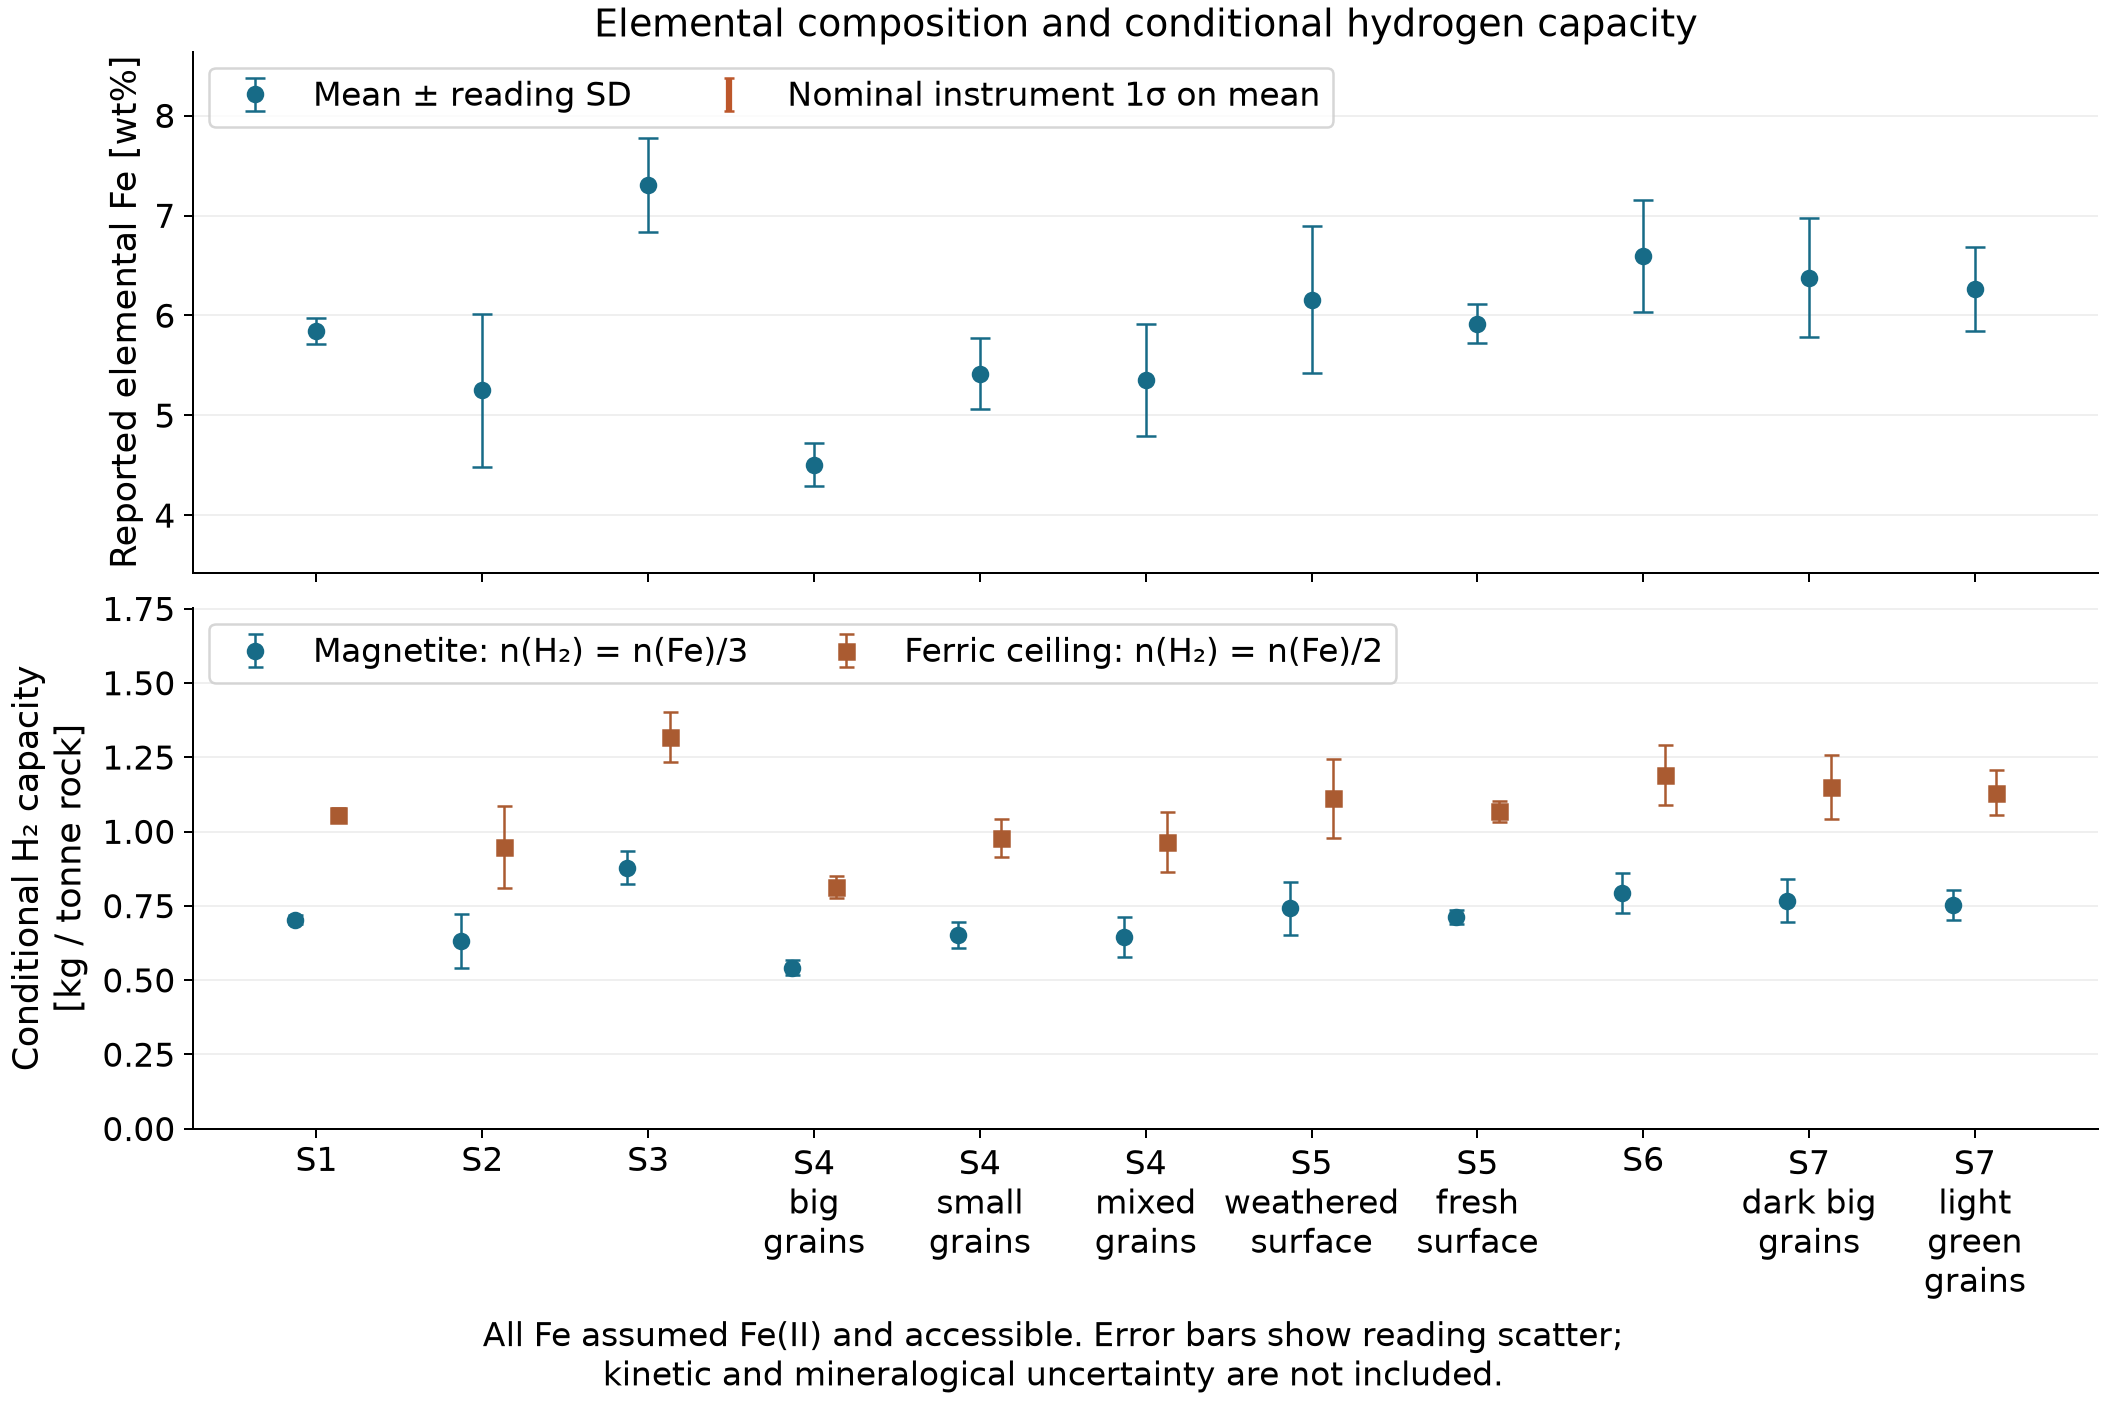

In [2]:
from olivine_hydrogen.data.process_xrf import process
process(make_plots=True)
samples = pd.read_csv(model_dir / 'data/processed/sample_summary.csv')
display(samples[['sample', 'n_readings', 'Fe_mean_wt_percent', 'Fe_sample_sd_wt_percent', 'magnetite_H2_kg_per_tonne_rock']])
display(Image(filename=str(model_dir / 'data/figures/fe_and_conditional_capacity.png')))


## Iron and the hydrogen limit

For the magnetite pathway, 3 moles of ferrous iron can produce 1 mole of hydrogen:

$$3FeO + H_2O \rightarrow Fe_3O_4 + H_2.$$

FeO is a redox proxy, not the measured mineral composition. We use the fresh surface of sample 5 as a reference. It is not a demonstrated optimum. The separate all-ferric electron ceiling is 1.5 times the magnetite value.

In [3]:
from olivine_hydrogen.batch import Setup, SCENARIOS, evaluate, capacity_mol, M_H2
from olivine_hydrogen.run_batch import run, fresh_eifel_setup
setup = fresh_eifel_setup()
print('Fe mass fraction:', setup.fe_mass_fraction)
print('Rock mass:', setup.rock_kg, 'kg')
print('Magnetite hydrogen ceiling:', capacity_mol(setup) * M_H2, 'kg')
summary, endpoints = run()


Fe mass fraction: 0.05918704059999999
Rock mass: 10000.0 kg
Magnetite hydrogen ceiling: 7.121734049883784 kg


{
  "ceiling_h2_kg": 7.121734049883784,
  "ceiling_gross_kwh": 105.20193416766942,
  "heat_kwh_thermal": 765.4792633333333,
  "pump_kwh": 101.95096961063628
}


## Reaction time and recovery

We compare zero production and half-times of 10 years, 1 year and 3 days. These are uncalibrated sensitivities, not confidence limits or measured rates. The last case is an accelerated engineering target.

The initial fluid contains 20 tonnes of water and 5.26 tonnes of salt. Hydrogen may remain dissolved at 120 bar. Each batch endpoint is then flashed once at 10 bar; 90% of the liberated gas is collected. Endpoints must not be added as repeated production from the same batch.

,scenario,time_days,generated_h2_kg,collected_h2_kg,gross_electricity_kwh
0,zero,3.0,0.00000,0.00000,0.00000
1,zero,365.0,0.00000,0.00000,0.00000
2,zero,3650.0,0.00000,0.00000,0.00000
3,ten_year_assumption,3.0,0.00406,0.00000,0.00000
4,ten_year_assumption,365.0,0.47692,0.33195,5.53197
5,ten_year_assumption,3650.0,3.56087,3.10772,51.79013
6,exploratory_assumption,3.0,0.04046,0.00000,0.00000
7,exploratory_assumption,365.0,3.56087,3.10772,51.79013
8,exploratory_assumption,3650.0,7.11478,6.30649,105.09761
9,accelerated_target,3.0,3.56087,3.10772,51.79013


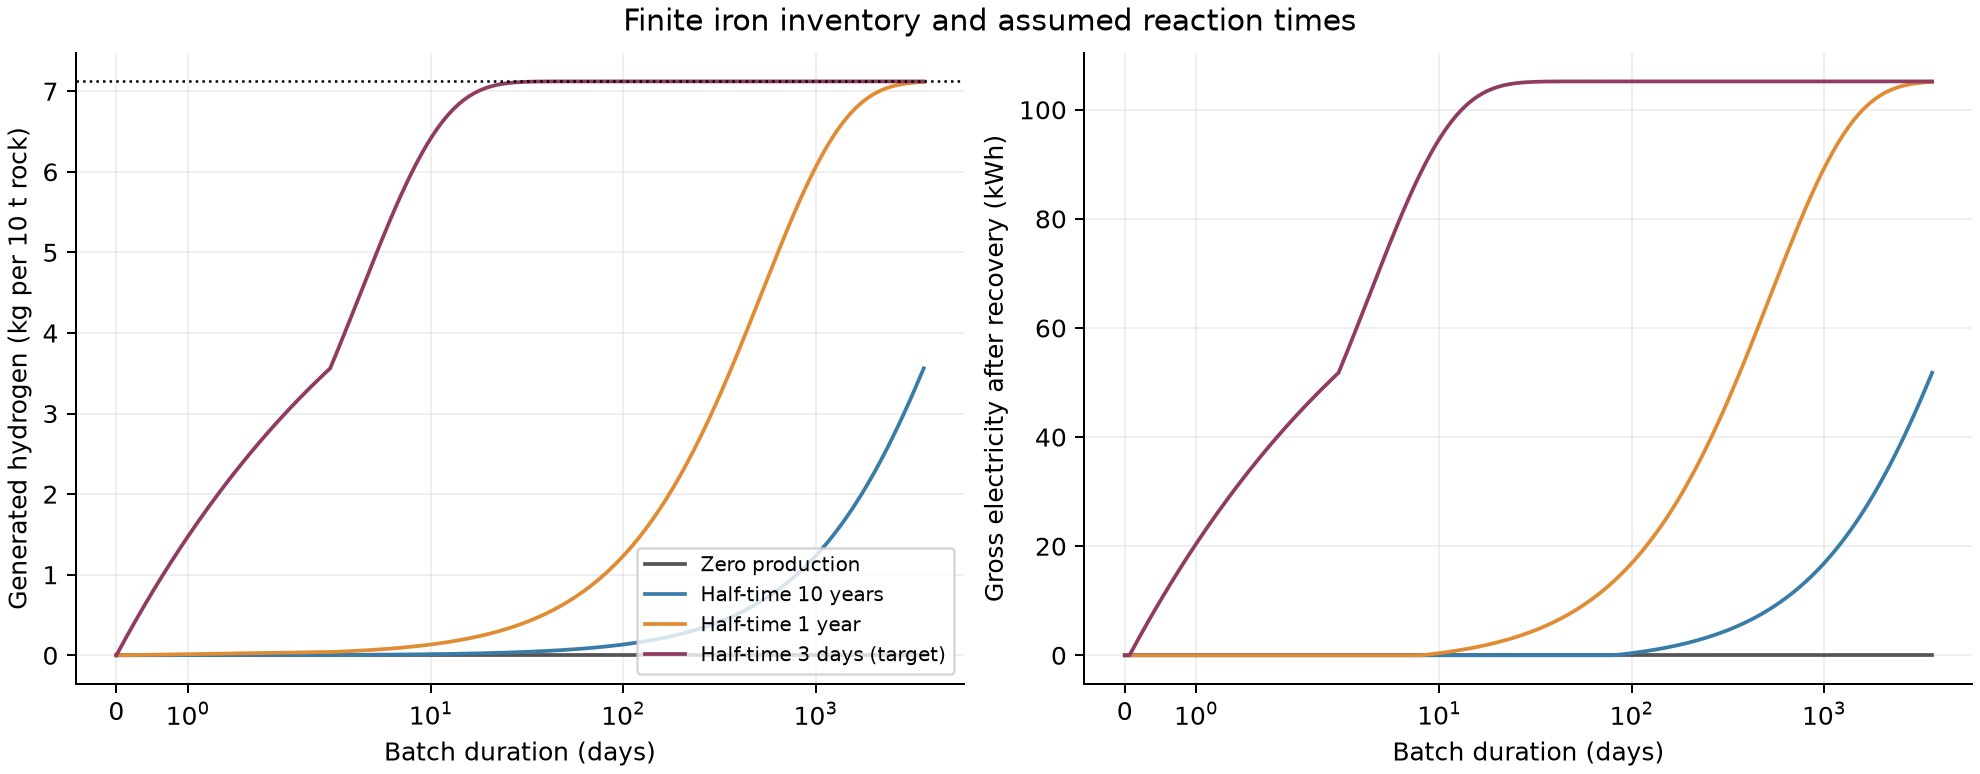

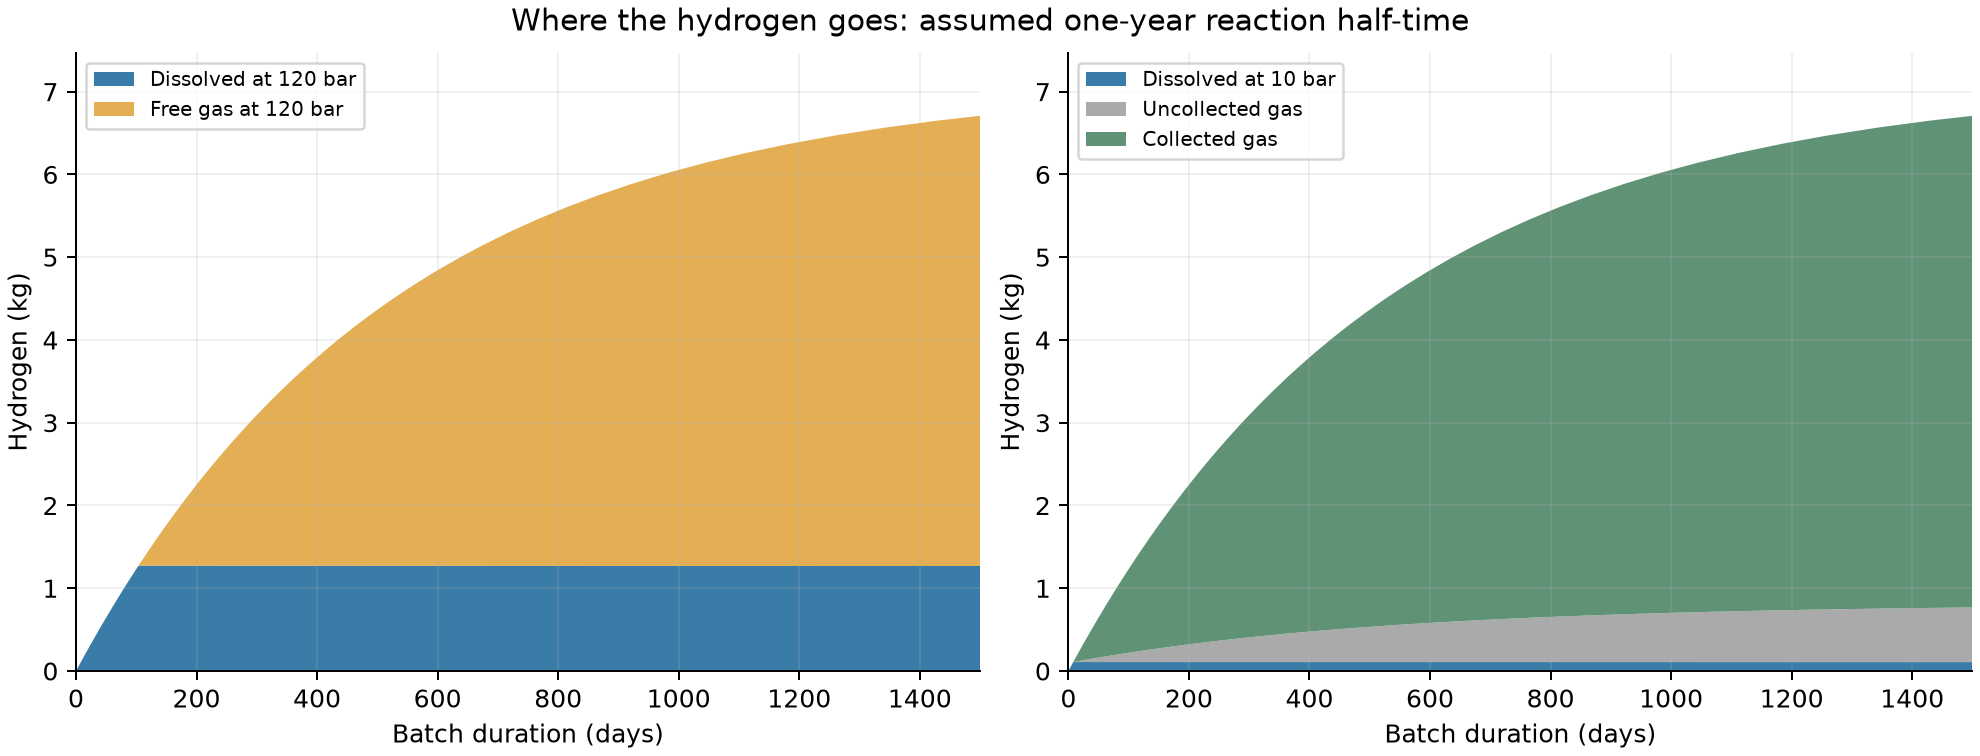

In [4]:
table = pd.DataFrame(endpoints)
display(table[['scenario', 'time_days', 'generated_h2_kg', 'collected_h2_kg', 'gross_electricity_kwh']].round(5))
display(Image(filename=str(model_dir / 'results/batch_scenarios.png')))
display(Image(filename=str(model_dir / 'results/partition_recovery.png')))


## How much electricity is left?

Gross electricity uses collected hydrogen, its lower heating value of 33.33 kWh/kg, and 50% conversion efficiency. We keep thermal heating demand separate from electrical demand.

The standalone case includes electrical heating from 20 to 50°C and pressurization from 1 to 120 bar. The warm, already pressurized case subtracts only a selected extra 5 bar pump differential. It excludes several costs and is not a full project net-energy estimate. Recycling fluid after the 10-bar separator needs additional repressurization.

gross_electricity_kwh 105.2
sensible_heat_kwh_thermal 765.48
initial_pump_electricity_kwh 101.95
standalone_balance_kwh -802.52


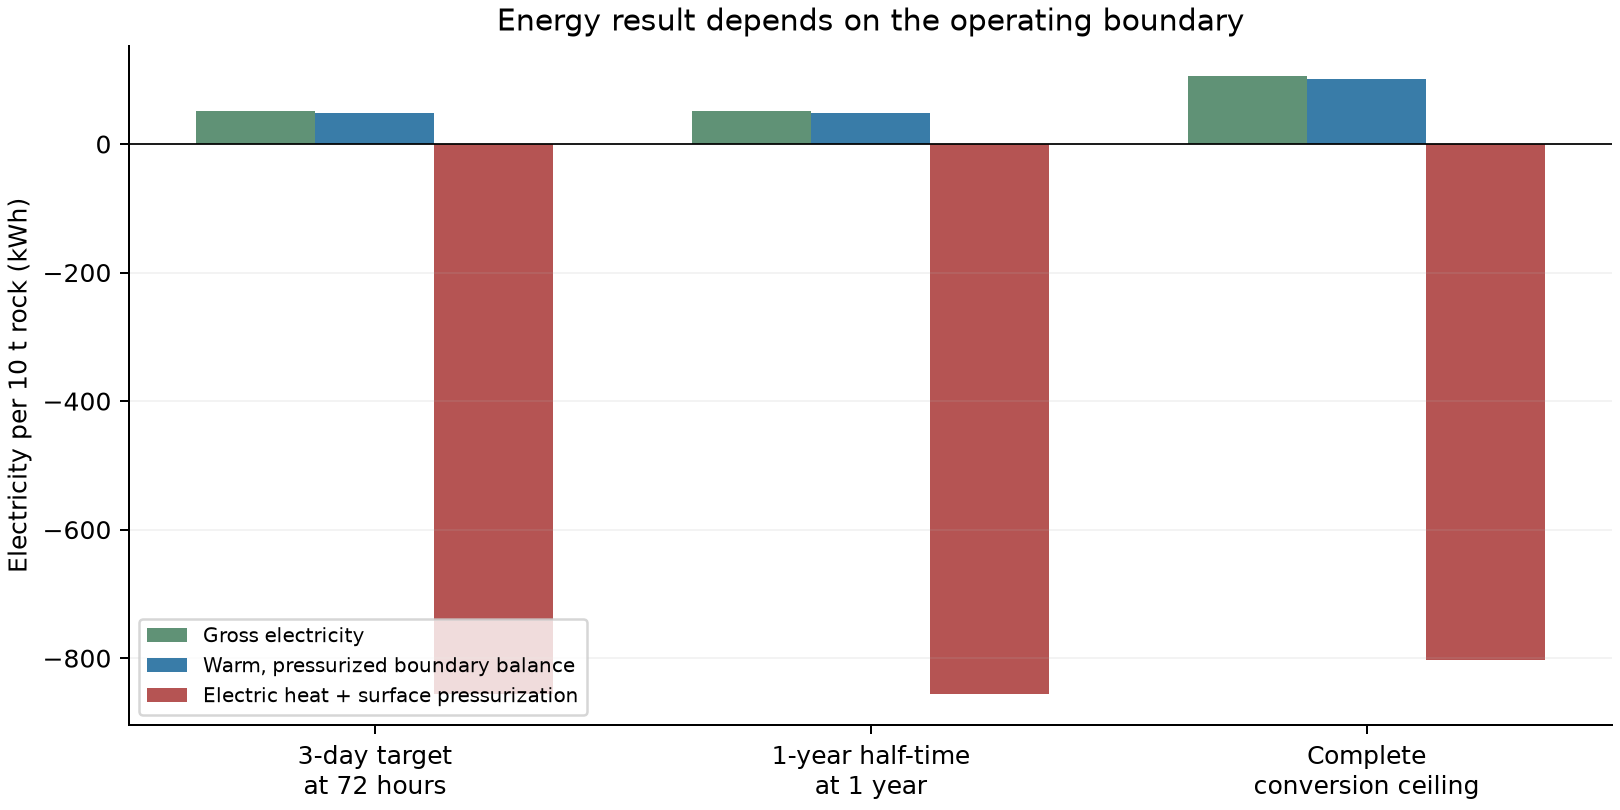

In [5]:
ceiling = summary['complete_conversion_endpoint']
for name in ['gross_electricity_kwh', 'sensible_heat_kwh_thermal', 'initial_pump_electricity_kwh', 'standalone_balance_kwh']:
    print(name, round(ceiling[name], 2))
display(Image(filename=str(model_dir / 'results/energy_balance.png')))


## Changing the assumptions

Here only half of the measured iron is taken to be accessible. The water-to-rock ratio still refers to water mass, not total brine mass. NaCl molality must stay within the solubility correlation's range (0–5 mol/kg water), including the small increase as water reacts.

,time_days,generated_h2_kg,collected_h2_kg,gross_electricity_kwh
0,3.0,0.020229,0.000000,0.000000
1,365.0,1.780434,1.505204,25.084222
2,3650.0,3.557390,3.104588,51.737967


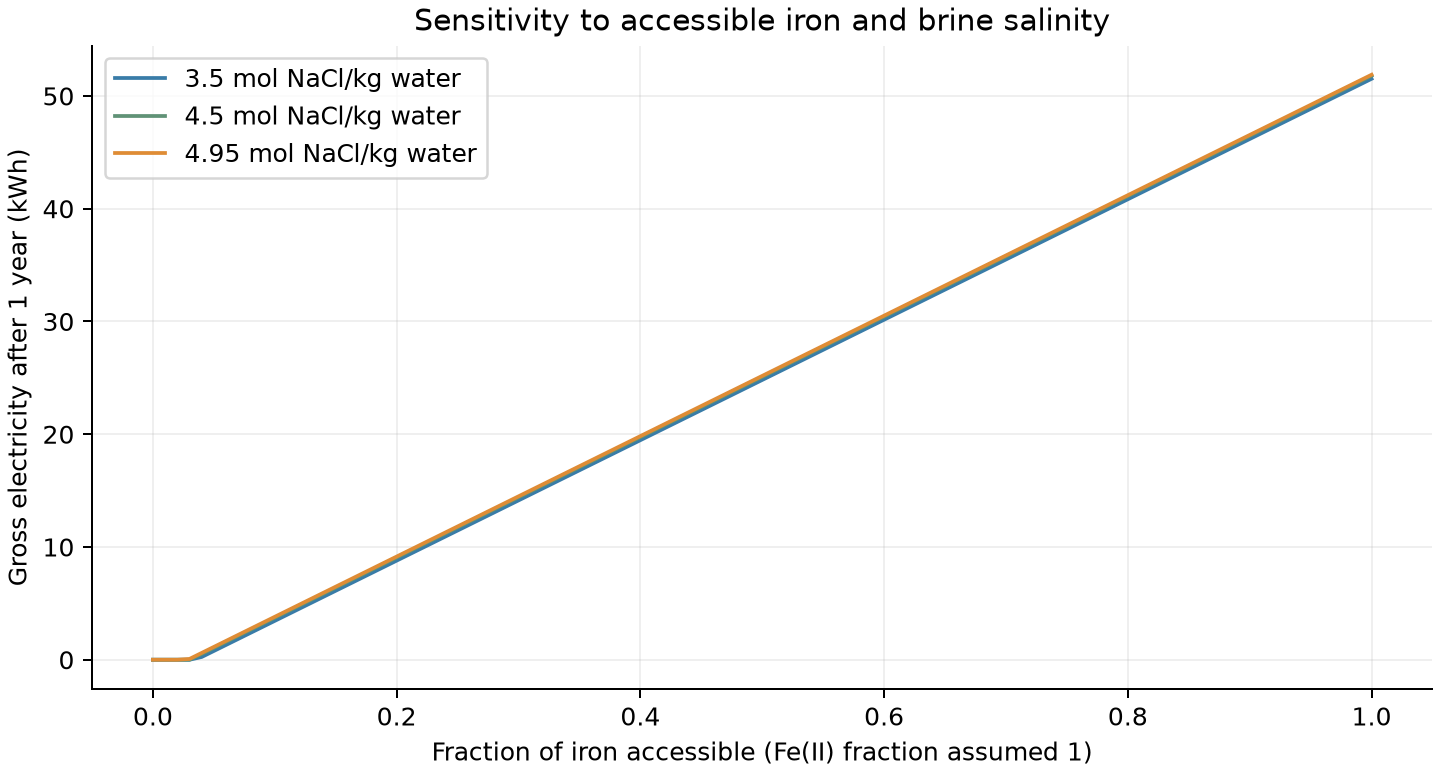

In [6]:
less_accessible = replace(setup, accessible_fraction=0.5)
comparison = evaluate([3, 365, 3650], 365, less_accessible)
display(pd.DataFrame(comparison)[['time_days', 'generated_h2_kg', 'collected_h2_kg', 'gross_electricity_kwh']])
display(Image(filename=str(model_dir / 'results/sensitivity.png')))


## Stationary water, circulation and fresh-water renewal

These operations do not mean the same thing. Stationary operation retains the initial water and hydrogen until the endpoint. Recirculation moves the same fluid around a closed loop, with no fresh-water supply or gas-stripping unit. Once-through operation adds fresh brine and removes an equal mass of water, carrying dissolved hydrogen with it.

Here we start each case with 10 tonnes of rock and 20 tonnes of water at 50°C and 120 bar. Flowing cases circulate or replace 20 tonnes of water per three days. We follow the system for 365 days. The once-through case therefore needs much more water than the other cases; its additional feed is reported separately.

This is a well-mixed model with a finite iron inventory. It is separate from the spatial DARTS model below.

In [7]:
from olivine_hydrogen.feedback.model import Config as FeedbackConfig
from olivine_hydrogen.feedback.run import run_suite as run_feedback_suite

feedback_setup = FeedbackConfig(fe_mass_fraction=setup.fe_mass_fraction)
feedback_summary = run_feedback_suite(output=model_dir / 'feedback/output', cfg=feedback_setup)
feedback_rows = []
for case_name, case in feedback_summary['cases'].items():
    scenario, mode = case_name.split('/')
    feedback_rows.append({'scenario': scenario, 'mode': mode, **case['final']})
feedback_endpoints = pd.DataFrame(feedback_rows).set_index(['scenario', 'mode'])
print('Comparison duration:', feedback_setup.duration_days, 'days')
display(feedback_endpoints[[
    'generated_h2_kg', 'retained_h2_kg', 'exported_h2_kg',
    'outlet_collected_h2_kg', 'endpoint_collected_h2_kg'
]].round(5))

Comparison duration: 365.0 days


generated_h2_kg  retained_h2_kg  \
scenario                      mode                                             
no_feedback_null              stationary             3.56087         3.56087   
                              recirculating          3.56087         3.56087   
                              once_through           3.56087         0.01961   
intrinsic_limited             stationary             4.10858         4.10858   
                              recirculating          4.10858         4.10858   
                              once_through           4.10858         0.01842   
film_only_hypothesis          stationary             2.32290         2.32290   
                              recirculating          3.56720         3.56720   
                              once_through           3.56720         0.02018   
inhibition_only_hypothesis    stationary             2.70833         2.70833   
                              recirculating          2.70833         2.70833   
                              once_through           4.04881         0.01882   
contact_inhibition_hypothesis stationary             1.34788         1.34788   
                              recirculating          2.20126         2.20126   
                              once_through           3.51078         0.02045   
closure_hypothesis            stationary             1.05122         1.05122   
                              recirculating          1.33304         1.33304   
                              once_through           1.73862         0.00738   
opening_hypothesis            stationary             1.62935         1.62935   
                              recirculating          2.95650         2.95650   
                              once_through           4.89745         0.02744   
zero_source                   stationary             0.00000         0.00000   
                              recirculating          0.00000         0.00000   
                              once_through           0.00000         0.00000   

                                             exported_h2_kg  \
scenario                      mode                            
no_feedback_null              stationary            0.00000   
                              recirculating         0.00000   
                              once_through          3.54126   
intrinsic_limited             stationary            0.00000   
                              recirculating         0.00000   
                              once_through          4.09016   
film_only_hypothesis          stationary            0.00000   
                              recirculating         0.00000   
                              once_through          3.54703   
inhibition_only_hypothesis    stationary            0.00000   
                              recirculating         0.00000   
                              once_through          4.02999   
contact_inhibition_hypothesis stationary            0.00000   
                              recirculating         0.00000   
                              once_through          3.49033   
closure_hypothesis            stationary            0.00000   
                              recirculating         0.00000   
                              once_through          1.73124   
opening_hypothesis            stationary            0.00000   
                              recirculating         0.00000   
                              once_through          4.87001   
zero_source                   stationary            0.00000   
                              recirculating         0.00000   
                              once_through          0.00000   

                                             outlet_collected_h2_kg  \
scenario                      mode                                    
no_feedback_null              stationary                        0.0   
                              recirculating                     0.0   
                              once_throug

## Does flow increase hydrogen formation?

The no-feedback null isolates the finite-inventory reaction law without changes in geometry, contact or inhibition. It can be checked against its analytical solution. The intrinsic-limited case retains the geometry factors but is the null comparison for a benefit from flow. It has an assumed positive intrinsic rate, but neither fluid contact nor dissolved hydrogen limits that rate. Generation should then be the same in the three modes. Once-through flow can still remove hydrogen from the reactor, so retained hydrogen and generated hydrogen must be shown separately. The zero-source case is a separate control in which no hydrogen forms.

The film-only and inhibition-only cases first separate two possible effects of flow. The contact-and-inhibition case assumes that mixing improves fluid contact and that dissolved hydrogen slows the reaction. The closure and opening cases change the assumed effects of expansion, pore access, passivation and accessible surface area. These are hypotheses, not parameters fitted to the XRF data. The possible increase in surface area is capped at five times its initial value.

The model does not calculate stress or propagating fractures. Its porosity and surface-area factors describe proposed feedbacks in one mixed compartment; they are not native DARTS fracture results.

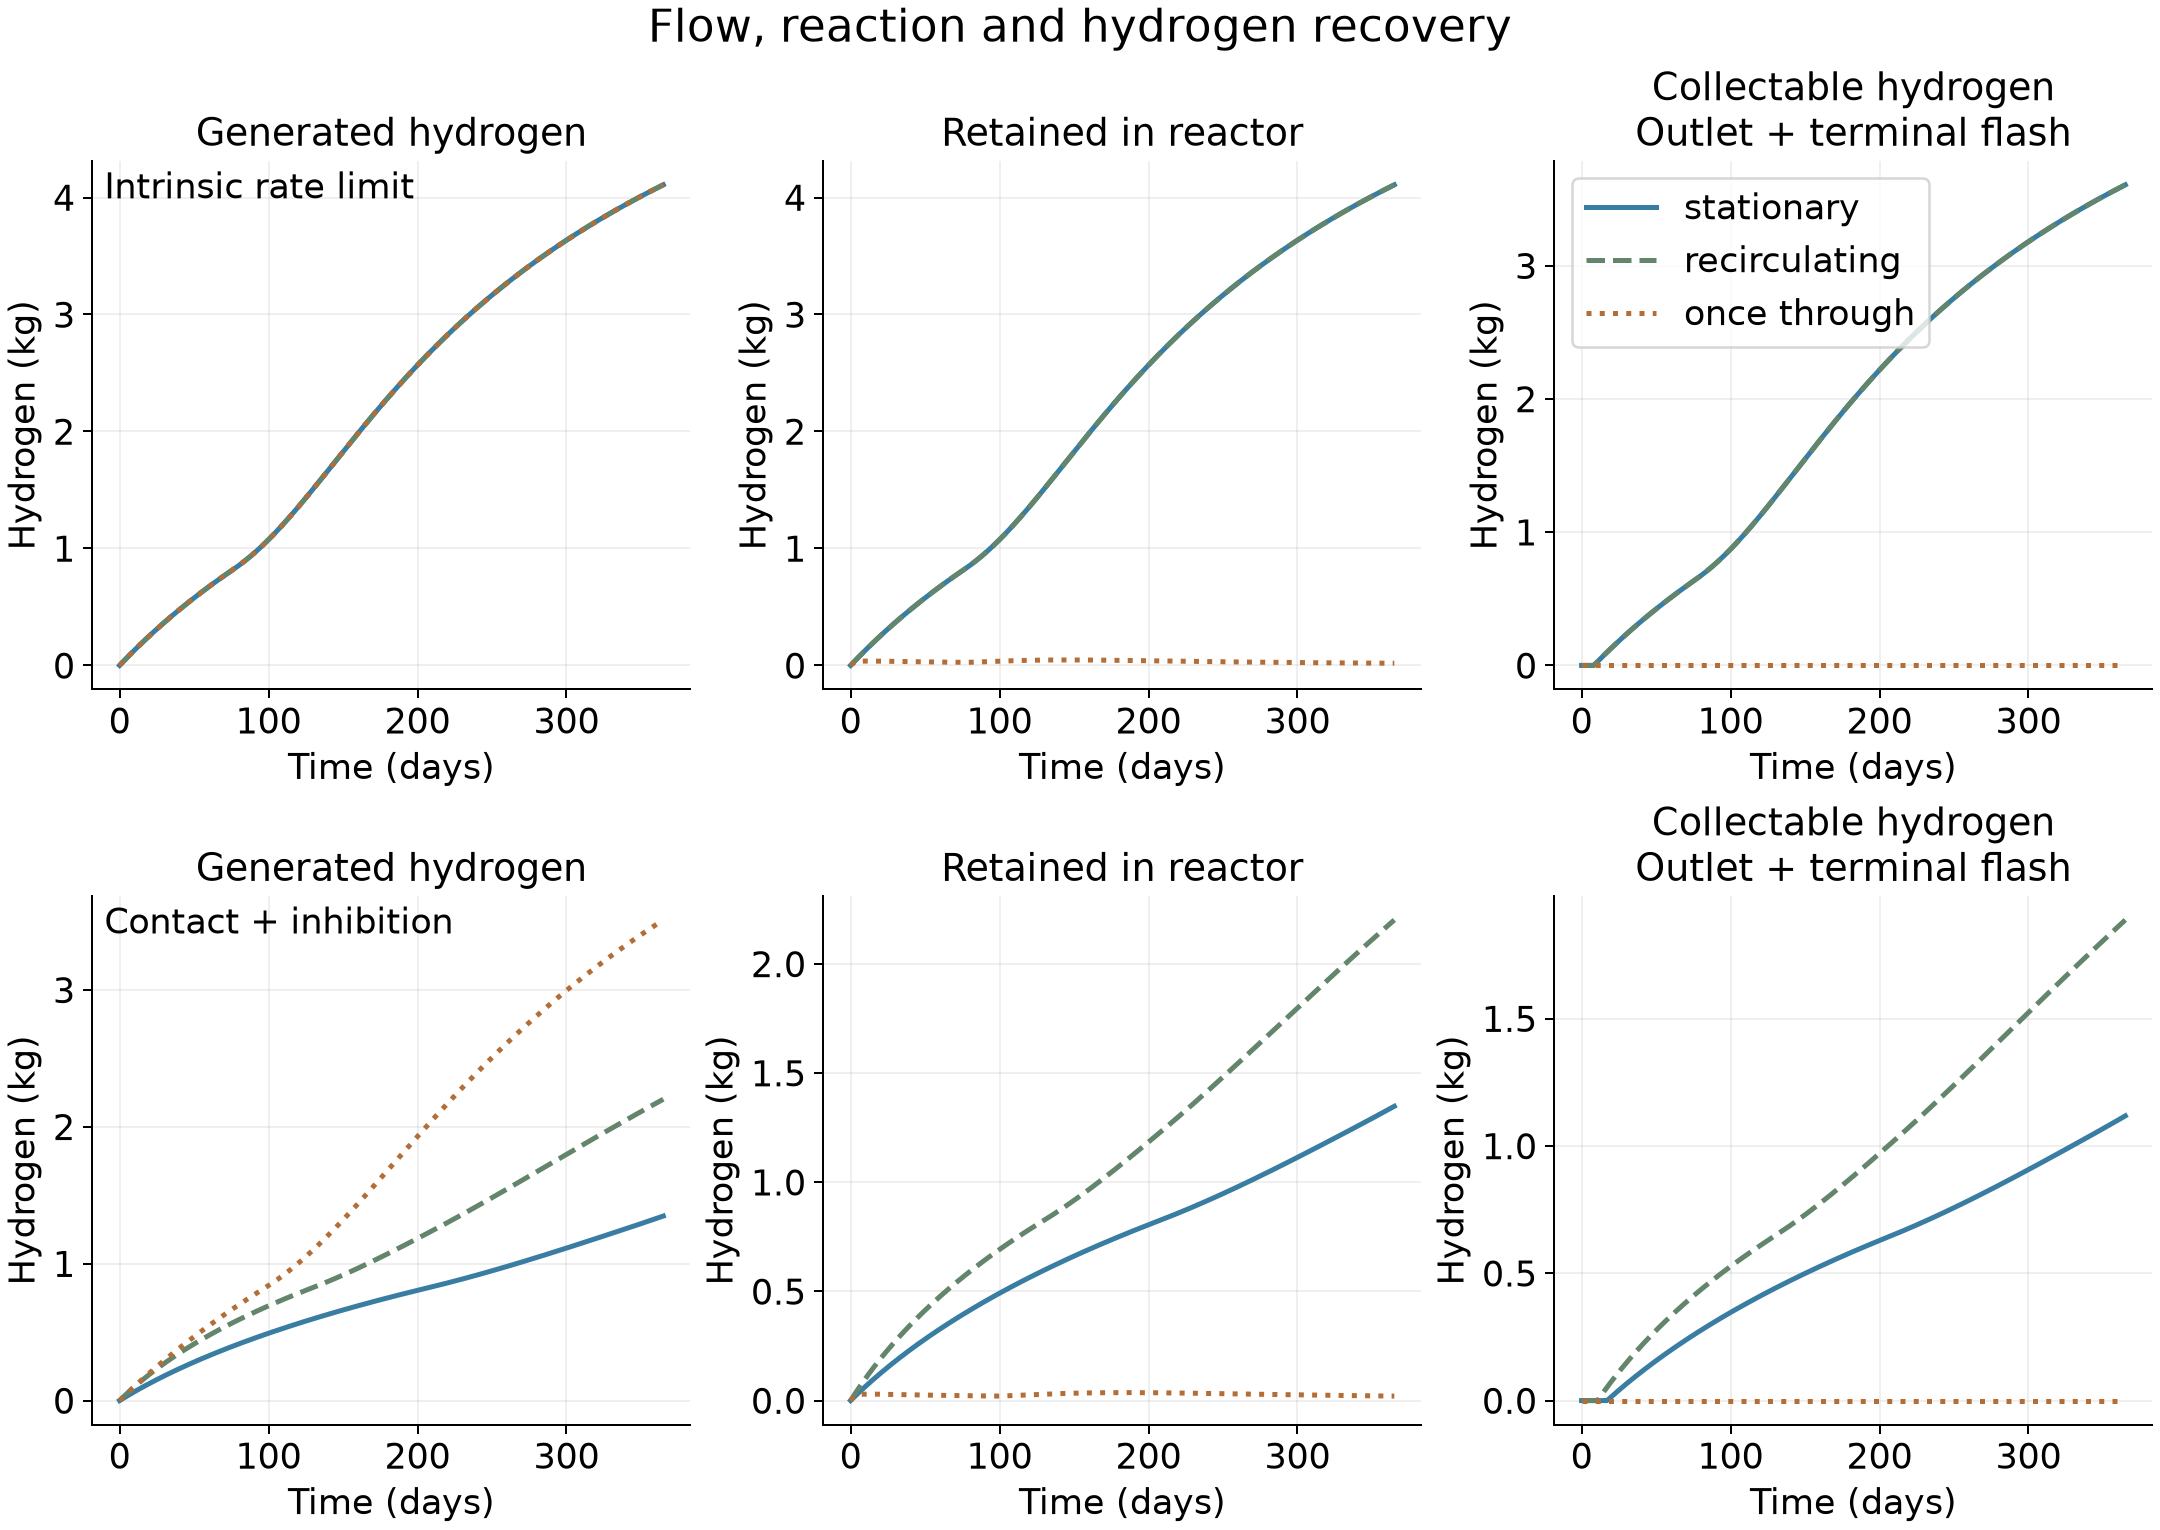

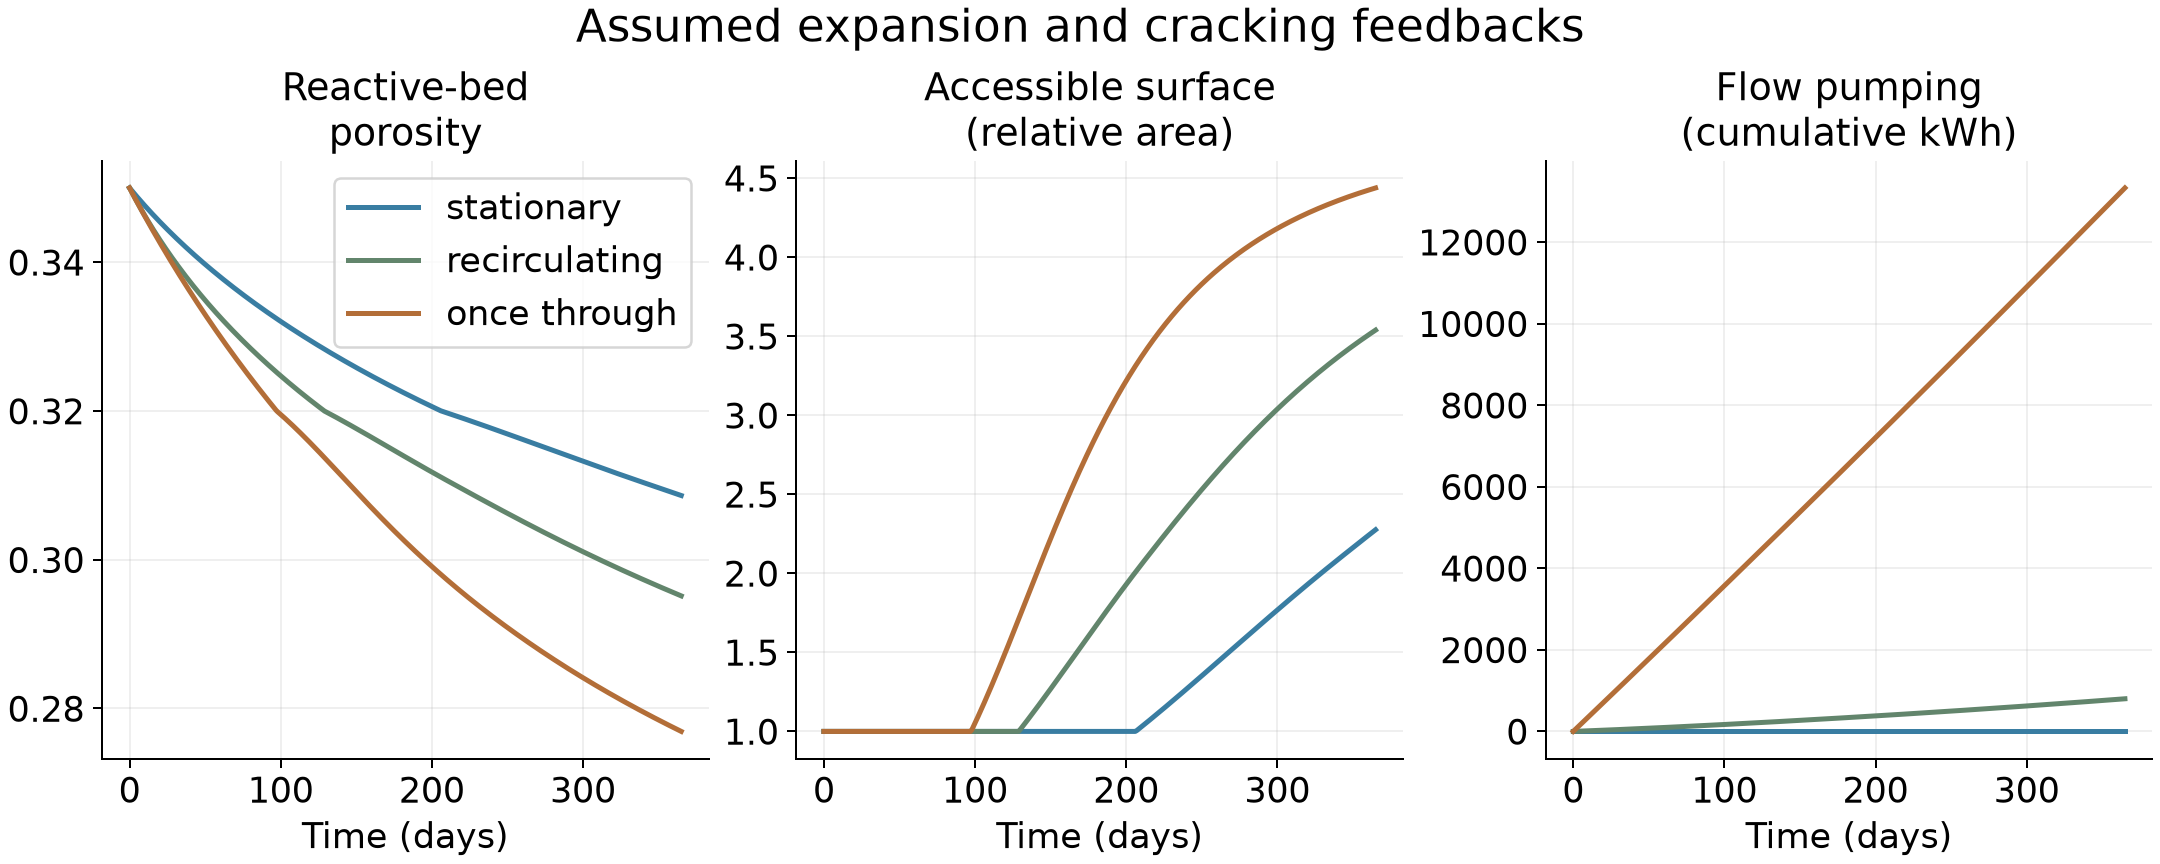

Ratios at the final time; the stationary value is the reference:


generated_vs_stationary  \
scenario                      mode                                     
no_feedback_null              recirculating                   1.0000   
                              once_through                    1.0000   
intrinsic_limited             recirculating                   1.0000   
                              once_through                    1.0000   
film_only_hypothesis          recirculating                   1.5357   
                              once_through                    1.5357   
inhibition_only_hypothesis    recirculating                   1.0000   
                              once_through                    1.4949   
contact_inhibition_hypothesis recirculating                   1.6331   
                              once_through                    2.6047   
closure_hypothesis            recirculating                   1.2681   
                              once_through                    1.6539   
opening_hypothesis            recirculating                   1.8145   
                              once_through                    3.0058   

                                             retained_vs_stationary  
scenario                      mode                                   
no_feedback_null              recirculating                  1.0000  
                              once_through                   0.0055  
intrinsic_limited             recirculating                  1.0000  
                              once_through                   0.0045  
film_only_hypothesis          recirculating                  1.5357  
                              once_through                   0.0087  
inhibition_only_hypothesis    recirculating                  1.0000  
                              once_through                   0.0069  
contact_inhibition_hypothesis recirculating                  1.6331  
                              once_through                   0.0152  
closure_hypothesis            recirculating                  1.2681  
                              once_through                   0.0070  
opening_hypothesis            recirculating                  1.8145  
                              once_through                   0.0168

In [8]:
display(Image(filename=str(model_dir / 'feedback/output/hydrogen_comparison.png')))
display(Image(filename=str(model_dir / 'feedback/output/feedback_and_pumping.png')))
ratio_rows = []
for scenario, modes in feedback_summary['end_time_ratios'].items():
    for mode, values in modes.items():
        if mode != 'stationary' and scenario != 'zero_source':
            ratio_rows.append({'scenario': scenario, 'mode': mode, **values})
print('Ratios at the final time; the stationary value is the reference:')
display(pd.DataFrame(ratio_rows).set_index(['scenario', 'mode']).round(4))

## Recovery and operating costs in the comparison

Each parcel of once-through effluent is flashed at 10 bar when it leaves. A large cumulative dissolved export does not necessarily provide gas: a dilute outlet may remain below its solubility limit after pressure reduction. The model also calculates one possible final flash of the fluid remaining in the reactor. This terminal recovery is an independent endpoint and must not be added repeatedly over time.

Total collectable hydrogen means gas already collected from the outlet plus the potential terminal collection. The energy table shows this corresponding gross electricity, pumping, heating of new feed and a standalone engineering balance. Initial heating and pressurization are also deducted from that balance. Continuous heat losses and other plant loads are not included, so it is not a complete project energy assessment. Pressure and temperature are imposed conditions. A high required pump head is a diagnostic of the assumptions, not proof that the selected flow can be maintained.

In [9]:
feedback_energy = feedback_endpoints.loc[
    ['intrinsic_limited', 'contact_inhibition_hypothesis'],
    ['feed_water_kg', 'total_deliverable_h2_kg', 'gross_electricity_kwh',
     'flow_pump_kwh', 'new_feed_heater_kwh', 'standalone_engineering_balance_kwh']
].copy()
feedback_energy.insert(0, 'additional_feed_water_tonnes', feedback_energy.pop('feed_water_kg') / 1000)
display(feedback_energy.round(3))
head_flags = [name for name, case in feedback_summary['cases'].items()
              if case['head_diagnostic_limit_exceeded']]
print('Cases exceeding the selected pump-head diagnostic:', head_flags or 'none')

additional_feed_water_tonnes  \
scenario                      mode                                          
intrinsic_limited             stationary                            0.000   
                              recirculating                         0.000   
                              once_through                       2433.333   
contact_inhibition_hypothesis stationary                            0.000   
                              recirculating                         0.000   
                              once_through                       2433.333   

                                             total_deliverable_h2_kg  \
scenario                      mode                                     
intrinsic_limited             stationary                       3.607   
                              recirculating                    3.607   
                              once_through                     0.000   
contact_inhibition_hypothesis stationary                       1.118   
                              recirculating                    1.888   
                              once_through                     0.000   

                                             gross_electricity_kwh  \
scenario                      mode                                   
intrinsic_limited             stationary                    60.117   
                              recirculating                 60.117   
                              once_through                   0.000   
contact_inhibition_hypothesis stationary                    18.633   
                              recirculating                 31.456   
                              once_through                   0.000   

                                             flow_pump_kwh  \
scenario                      mode                           
intrinsic_limited             stationary             0.000   
                              recirculating       1032.607   
                              once_through       13430.519   
contact_inhibition_hypothesis stationary             0.000   
                              recirculating        800.614   
                              once_through       13330.254   

                                             new_feed_heater_kwh  \
scenario                      mode                                 
intrinsic_limited             stationary                   0.000   
                              recirculating                0.000   
                              once_through             88963.426   
contact_inhibition_hypothesis stationary                   0.000   
                              recirculating                0.000   
                              once_through             88963.426   

                                             standalone_engineering_balance_kwh  
scenario                      mode                                               
intrinsic_limited             stationary                               -847.602  
                              recirculating                           -1880.209  
                              once_through                          -103301.664  
contact_inhibition_hypothesis stationary                               -889.086  
                              recirculating                           -1676.876  
                              once_through                          -103201.399

Cases exceeding the selected pump-head diagnostic: none


## Three-dimensional DARTS bed

This is a flow-through alternative, not Darcy flow through an open cavern. We assume a 2 × 2 m bed, porosity 0.35, 1000 mD permeability, and a one-year conversion half-time. The 10-tonne mineral inventory sets the bed height. We inject 20 tonnes of water plus salt over 72 hours; the initial porewater is additional.

The native model transports H₂, H₂O and NaCl. Its mineral source consumes finite iron and water, and it only commits reaction after accepted timesteps. Hydrogen leaving in solution is kept separate from collected gas. This cell runs the actual native simulation.

A hydrogen–water contact is a boundary between free gas and brine, not between dissolved hydrogen and water. This model starts with brine and no free gas. Gravity and gas saturation allow vertical segregation if gas forms, but capillary pressure is set to zero and the bed has no calibrated layering. The default run has no free gas and therefore no contact. A natural hydrogen reservoir with an existing gas cap needs a different initial inventory and well completion; the thesis explains this using the minor report.

generated_H2_kg 0.04045787615518955
aqueous_H2_exported_kg 0.038585278315824034
remaining_dissolved_H2_kg 0.0018728577209547207
collected_H2_kg 0.0
gross_electricity_kwh 0.0
Native relative balance errors: {'H2': np.float64(7.037138699691811e-11), 'H2O': np.float64(5.1005982580374265e-15), 'NaCl': np.float64(2.136131861084776e-14)}


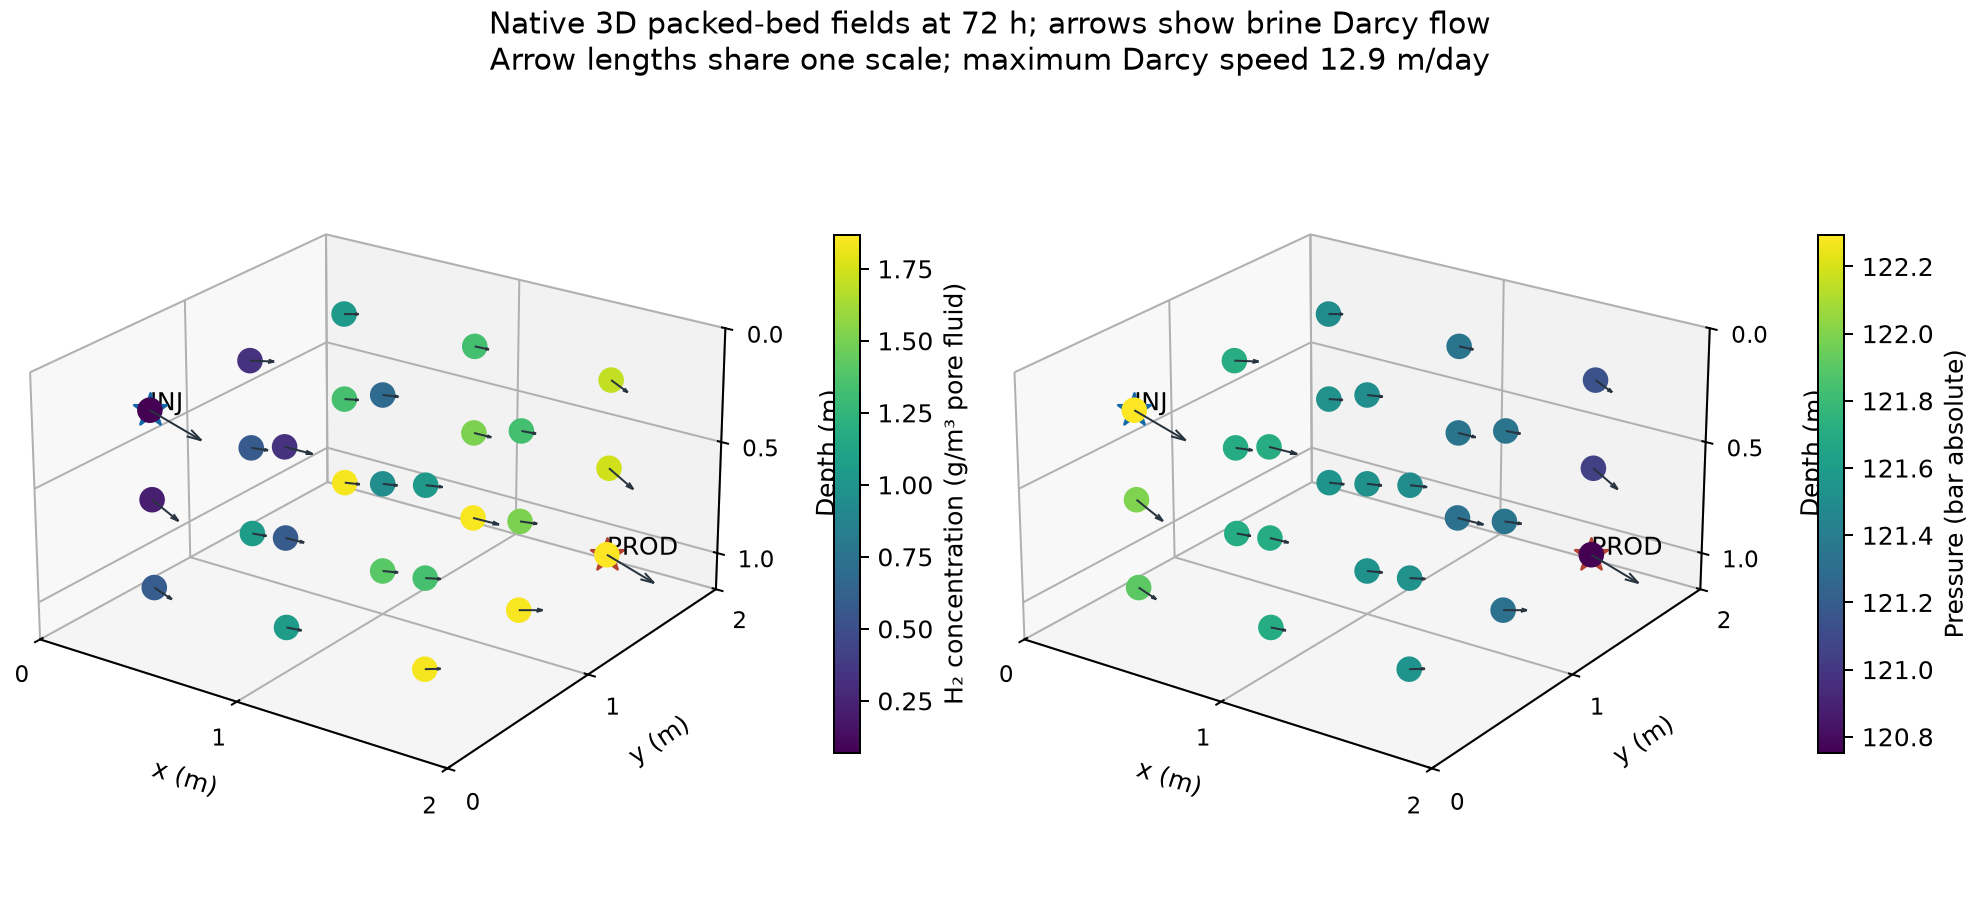

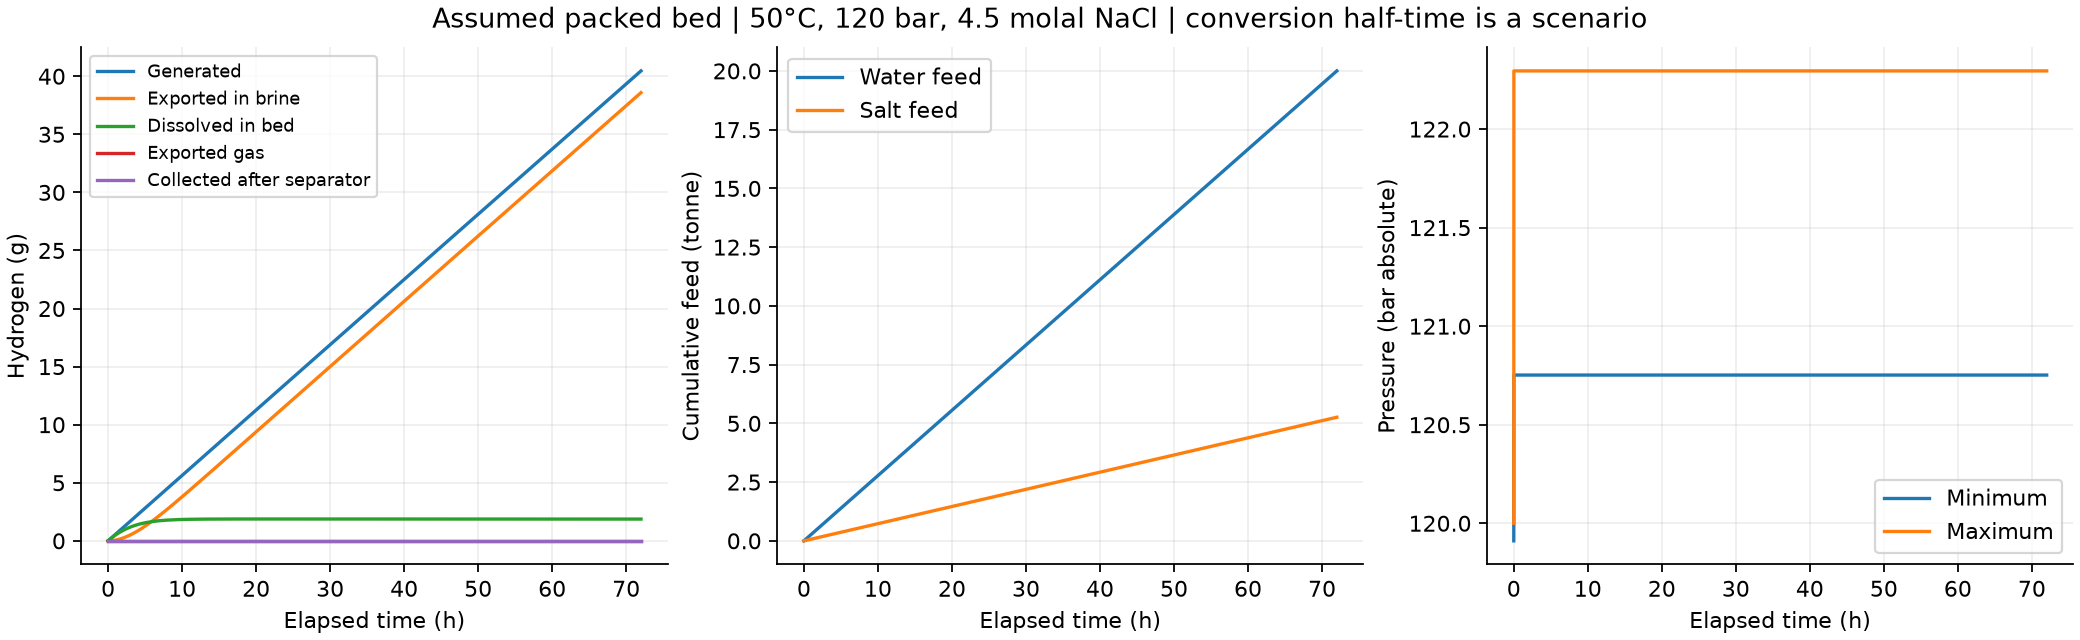

In [10]:
from olivine_hydrogen.darts.run import run_case
# Capture native progress text while retaining the model outputs and balance checks.
with contextlib.redirect_stdout(io.StringIO()):
    flow, flow_history = run_case(output=model_dir / 'darts/output/reactive')
for name in ['generated_H2_kg', 'aqueous_H2_exported_kg', 'remaining_dissolved_H2_kg', 'collected_H2_kg', 'gross_electricity_kwh']:
    print(name, flow[name])
print('Native relative balance errors:', flow['max_native_relative_balance_error'])
display(Image(filename=str(model_dir / 'darts/output/reactive/packed_bed_3d.png')))
display(Image(filename=str(model_dir / 'darts/output/reactive/history.png')))


## Verification and interpretation

Conservation is necessary, but does not establish that an assumed rate is physically attainable. The reduced-feedback checks include hydrogen, water, salt and recovery balances, an intrinsic-rate null case, finite inventories and time refinement. These are separate from the native DARTS checks.

The native checks include source depletion, phase appearance, a zero-source control, time/interpolation refinement and a separate spatial sensitivity. The finer grid also changes the corner-cell well connections, so formal spatial convergence is not claimed.

The result is a framework for interpreting future reactor measurements. A circulation benefit only appears when the selected hypotheses give flow a mechanism to alter the rate. The model does not yet justify a production forecast or identify a kinetically optimal sand.

In [11]:
feedback_errors = pd.DataFrame({
    name: case['max_abs_balance_errors']
    for name, case in feedback_summary['cases'].items()
}).T
for column in feedback_errors:
    tolerance = 1e-6 if column in ['water_balance_error_kg', 'salt_balance_error_kg'] else 1e-9
    assert feedback_errors[column].max() < tolerance, column
analytic_generation = capacity_mol(feedback_setup) * M_H2 * (1 - np.exp(-np.log(2) * feedback_setup.duration_days / feedback_setup.half_time_days))
np.testing.assert_allclose(feedback_endpoints.loc['no_feedback_null', 'generated_h2_kg'], analytic_generation, rtol=1e-9, atol=1e-10)
null_generation = feedback_endpoints.loc['intrinsic_limited', 'generated_h2_kg']
np.testing.assert_allclose(null_generation, null_generation.iloc[0], rtol=2e-6, atol=1e-9)
assert (feedback_endpoints.loc['zero_source', 'generated_h2_kg'] == 0).all()
print('Largest absolute feedback balance errors [kg]:')
display(feedback_errors.max().rename('Maximum absolute error'))

feedback_validation = json.loads((model_dir / 'feedback/output/validation.json').read_text())
assert feedback_validation['passed']
print('Reduced-feedback numerical tests:', feedback_validation['tests_run'])

validation = json.loads((model_dir / 'darts/output/validation.json').read_text())
assert validation['passed']
assert max(flow['max_native_relative_balance_error'].values()) < 2e-5
print('Native checks passed:', sum(validation['checks'].values()))
print('Property and rollback tests:', validation['property_tests'])
display(pd.Series(validation['metrics'], name='Numerical sensitivity'))

Largest absolute feedback balance errors [kg]:


h2_balance_error_kg                   5.958655e-15
water_balance_error_kg                2.328306e-10
salt_balance_error_kg                 8.708656e-10
hydrogen_recovery_balance_error_kg    5.773160e-15
Name: Maximum absolute error, dtype: float64

Reduced-feedback numerical tests: 8
Native checks passed: 30
Property and rollback tests: 3


spatial_aqueous_H2_export_relative_difference                                               0.001802
spatial_remaining_dissolved_H2_difference_kg                                                -0.00007
spatial_pressure_range_difference_bar                       [0.20689248725444997, 1.597794864926641]
half_timestep_aqueous_H2_export_relative_difference                                              0.0
fine_interpolation_aqueous_H2_export_relative_difference                                         0.0
Name: Numerical sensitivity, dtype: object